In [21]:
#Import libraries
import warnings
warnings.filterwarnings('ignore') 
import csv
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import RepeatedKFold
import seaborn as sns
from sklearn.metrics import RocCurveDisplay
from scipy import stats
from sklearn.cluster import KMeans
from sklearn import metrics
import matplotlib.pyplot as plt
from itertools import product
from collections import defaultdict, Counter
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import roc_curve, auc, accuracy_score
import statistics
from random import shuffle
from sklearn.feature_selection import RFE
from sklearn.model_selection import RepeatedKFold
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix
from sklearn.metrics import classification_report
from matplotlib.pyplot import figure
from sklearn.metrics import accuracy_score     
from sklearn.feature_selection import SelectFromModel
import math
from scipy.stats.stats import pearsonr
from matplotlib.colors import Normalize

In [9]:
# Read your .csv file containing the independent variables and the target
df = pd.read_csv('features_fromMD.csv') 

X = df.iloc[:,1:49]
Y = df.iloc[:,[49]]

In [12]:
def SelectFeatures(X, Y):
    # Accuracy scores to be saved here
    all_acc = []
    # Most important features for every iteration to be saved here
    MIF = []

    # Define a random state to split the data into 100 unique testing and training folds
    random_state = 12883823
    rkf = RepeatedKFold(n_splits=2, n_repeats=100, random_state=random_state)
    rkf.get_n_splits(X, Y)

    for train, test in rkf.split(X):
        X_train, X_test = X.iloc[train, :], X.iloc[test, :]
        Y_train, Y_test = Y.iloc[train], Y.iloc[test]

        rf = RandomForestRegressor(random_state=12883823, n_jobs=-1)
        rf.fit(X_train, Y_train)
        f_i = list(zip(X.columns, rf.feature_importances_))
        f_i.sort(key=lambda x: -x[1])
        MIF.append(f_i)

        pred_values = rf.predict(X_test)
        acc = accuracy_score(pred_values.round(), Y_test)  # Assuming Y_test is binary
        print('Accuracy : {}'.format(acc))
        all_acc.append(acc)

    return all_acc, MIF

In [14]:
all_acc, MIF = SelectFeatures(X, Y)

Accuracy : 0.6666666666666666
Accuracy : 0.8571428571428571
Accuracy : 0.8
Accuracy : 0.42857142857142855
Accuracy : 0.7333333333333333
Accuracy : 0.7142857142857143
Accuracy : 0.6666666666666666
Accuracy : 0.5
Accuracy : 0.4
Accuracy : 0.8571428571428571
Accuracy : 0.8
Accuracy : 0.7857142857142857
Accuracy : 0.8
Accuracy : 0.7857142857142857
Accuracy : 0.4666666666666667
Accuracy : 0.7142857142857143
Accuracy : 0.8
Accuracy : 1.0
Accuracy : 0.8
Accuracy : 0.8571428571428571
Accuracy : 0.7333333333333333
Accuracy : 0.7857142857142857
Accuracy : 0.6
Accuracy : 0.42857142857142855
Accuracy : 0.8
Accuracy : 0.7142857142857143
Accuracy : 0.8666666666666667
Accuracy : 0.7142857142857143
Accuracy : 0.6666666666666666
Accuracy : 0.6428571428571429
Accuracy : 0.8666666666666667
Accuracy : 0.5714285714285714
Accuracy : 0.7333333333333333
Accuracy : 0.7857142857142857
Accuracy : 0.8666666666666667
Accuracy : 0.5714285714285714
Accuracy : 0.6666666666666666
Accuracy : 0.7142857142857143
Accuracy

In [19]:
def GetTopFeatures(MIF, top_n=3, common_n=5):
    """
    Extract the top N features from each iteration in MIF and return the most common features.
    Returns:
    list: Most common features across all iterations.
    """
    top_n_items = []
    strings_only = []

    for data_list in MIF:
        sorted_list = sorted(data_list, key=lambda x: x[1], reverse=True)
        
        # Select the top N items and append to new list
        top_n_features = sorted_list[:top_n]
        top_n_items.append(top_n_features)

    for item_list in top_n_items:
        # Extract strings from each tuple
        strings = [item[0] for item in item_list]
        strings_only.extend(strings)

    counter = Counter(strings_only)
    most_common = counter.most_common(common_n)

    # Now plot the results
    figure(figsize=(9, 6.5), dpi=80)

    # Unpack the elements and frequencies
    elements, frequencies = zip(*most_common)
    pastel_palette = sns.color_palette("Pastel1", len(elements))
    
    # Plot the bar chart with pastel colors
    plt.bar(elements, frequencies, color=pastel_palette, edgecolor=".01",)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel('Feature', fontsize=16)
    plt.ylabel('Importance', fontsize=16)
    #plt.title('Most important features',fontsize=16)
    plt.show()
    
    return most_common

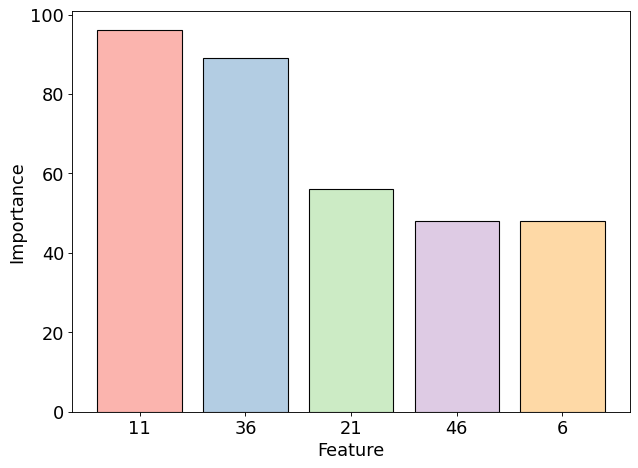

[('11', 96), ('36', 89), ('21', 56), ('46', 48), ('6', 48)]

In [20]:
GetTopFeatures(MIF, top_n=3)

Fold 0:
  Train: index=[ 0  6  7  9 12 13 14 17 18 20 22 24 26 28 30]
  Test:  index=[ 1  2  3  4  5  8 10 11 15 16 19 21 23 25 27 29]
{'0.0': {'precision': 0.6923076923076923, 'recall': 1.0, 'f1-score': 0.8181818181818181, 'support': 9}, '1.0': {'precision': 1.0, 'recall': 0.42857142857142855, 'f1-score': 0.6, 'support': 7}, 'accuracy': 0.75, 'macro avg': {'precision': 0.8461538461538461, 'recall': 0.7142857142857143, 'f1-score': 0.709090909090909, 'support': 16}, 'weighted avg': {'precision': 0.8269230769230769, 'recall': 0.75, 'f1-score': 0.7227272727272727, 'support': 16}}
    y_label
1       0.0
2       0.0
3       0.0
4       0.0
5       0.0
8       1.0
10      0.0
11      0.0
15      0.0
16      1.0
19      1.0
21      0.0
23      1.0
25      1.0
27      1.0
29      1.0
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1.]
Accuracy: 0.75
AUC: 0.8253968253968255
Fold 1:
  Train: index=[ 1  2  3  4  5  8 10 11 15 16 19 21 23 25 27 29]
  Test:  index=[ 0  6  7  9 12 13 14 17 18 20 22 2

{'0.0': {'precision': 0.8333333333333334, 'recall': 1.0, 'f1-score': 0.9090909090909091, 'support': 10}, '1.0': {'precision': 1.0, 'recall': 0.6, 'f1-score': 0.7499999999999999, 'support': 5}, 'accuracy': 0.8666666666666667, 'macro avg': {'precision': 0.9166666666666667, 'recall': 0.8, 'f1-score': 0.8295454545454545, 'support': 15}, 'weighted avg': {'precision': 0.888888888888889, 'recall': 0.8666666666666667, 'f1-score': 0.856060606060606, 'support': 15}}
    y_label
2       0.0
3       0.0
6       0.0
7       0.0
8       1.0
9       0.0
11      0.0
12      0.0
14      0.0
18      0.0
20      1.0
21      0.0
22      1.0
23      1.0
28      1.0
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1.]
Accuracy: 0.8666666666666667
AUC: 0.81
Fold 12:
  Train: index=[ 2  4  5  6 14 15 16 18 19 20 22 23 24 26 29]
  Test:  index=[ 0  1  3  7  8  9 10 11 12 13 17 21 25 27 28 30]
{'0.0': {'precision': 1.0, 'recall': 0.7272727272727273, 'f1-score': 0.8421052631578948, 'support': 11}, '1.0': {'precision':

{'0.0': {'precision': 0.8, 'recall': 0.8888888888888888, 'f1-score': 0.8421052631578948, 'support': 9}, '1.0': {'precision': 0.8333333333333334, 'recall': 0.7142857142857143, 'f1-score': 0.7692307692307692, 'support': 7}, 'accuracy': 0.8125, 'macro avg': {'precision': 0.8166666666666667, 'recall': 0.8015873015873016, 'f1-score': 0.8056680161943319, 'support': 16}, 'weighted avg': {'precision': 0.8145833333333334, 'recall': 0.8125, 'f1-score': 0.8102226720647774, 'support': 16}}
    y_label
1       0.0
2       0.0
5       0.0
8       1.0
9       0.0
10      0.0
11      0.0
13      0.0
16      1.0
18      0.0
19      1.0
21      0.0
23      1.0
26      1.0
28      1.0
30      1.0
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 1. 1. 1.]
Accuracy: 0.8125
AUC: 0.8571428571428572
Fold 25:
  Train: index=[ 1  2  5  8  9 10 11 13 16 18 19 21 23 26 28 30]
  Test:  index=[ 0  3  4  6  7 12 14 15 17 20 22 24 25 27 29]
{'0.0': {'precision': 0.8, 'recall': 0.8888888888888888, 'f1-score': 0.842105263157894

{'0.0': {'precision': 0.8181818181818182, 'recall': 1.0, 'f1-score': 0.9, 'support': 9}, '1.0': {'precision': 1.0, 'recall': 0.6666666666666666, 'f1-score': 0.8, 'support': 6}, 'accuracy': 0.8666666666666667, 'macro avg': {'precision': 0.9090909090909092, 'recall': 0.8333333333333333, 'f1-score': 0.8500000000000001, 'support': 15}, 'weighted avg': {'precision': 0.8909090909090909, 'recall': 0.8666666666666667, 'f1-score': 0.86, 'support': 15}}
    y_label
1       0.0
3       0.0
5       0.0
7       0.0
9       0.0
10      0.0
13      0.0
16      1.0
17      0.0
20      1.0
21      0.0
26      1.0
28      1.0
29      1.0
30      1.0
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1.]
Accuracy: 0.8666666666666667
AUC: 0.888888888888889
Fold 38:
  Train: index=[ 0  1  2  3  6  8 10 11 12 14 17 22 25 27 30]
  Test:  index=[ 4  5  7  9 13 15 16 18 19 20 21 23 24 26 28 29]
{'0.0': {'precision': 0.7272727272727273, 'recall': 1.0, 'f1-score': 0.8421052631578948, 'support': 8}, '1.0': {'precision': 

{'0.0': {'precision': 0.8333333333333334, 'recall': 1.0, 'f1-score': 0.9090909090909091, 'support': 10}, '1.0': {'precision': 1.0, 'recall': 0.6666666666666666, 'f1-score': 0.8, 'support': 6}, 'accuracy': 0.875, 'macro avg': {'precision': 0.9166666666666667, 'recall': 0.8333333333333333, 'f1-score': 0.8545454545454545, 'support': 16}, 'weighted avg': {'precision': 0.8958333333333334, 'recall': 0.875, 'f1-score': 0.8681818181818182, 'support': 16}}
    y_label
1       0.0
2       0.0
3       0.0
7       0.0
8       1.0
9       0.0
12      0.0
14      0.0
15      0.0
16      1.0
17      0.0
18      0.0
23      1.0
26      1.0
29      1.0
30      1.0
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1.]
Accuracy: 0.875
AUC: 0.8583333333333333
Fold 51:
  Train: index=[ 1  2  3  7  8  9 12 14 15 16 17 18 23 26 29 30]
  Test:  index=[ 0  4  5  6 10 11 13 19 20 21 22 24 25 27 28]
{'0.0': {'precision': 0.8, 'recall': 1.0, 'f1-score': 0.888888888888889, 'support': 8}, '1.0': {'precision': 1.0, 'rec

...

{'0.0': {'precision': 0.7, 'recall': 1.0, 'f1-score': 0.8235294117647058, 'support': 7}, '1.0': {'precision': 1.0, 'recall': 0.6666666666666666, 'f1-score': 0.8, 'support': 9}, 'accuracy': 0.8125, 'macro avg': {'precision': 0.85, 'recall': 0.8333333333333333, 'f1-score': 0.8117647058823529, 'support': 16}, 'weighted avg': {'precision': 0.8687499999999999, 'recall': 0.8125, 'f1-score': 0.8102941176470588, 'support': 16}}
    y_label
0       0.0
4       0.0
6       0.0
8       1.0
9       0.0
10      0.0
14      0.0
19      1.0
20      1.0
21      0.0
22      1.0
23      1.0
24      1.0
26      1.0
27      1.0
28      1.0
[0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 1. 0. 1. 1.]
Accuracy: 0.8125
AUC: 0.9047619047619047
Fold 143:
  Train: index=[ 0  4  6  8  9 10 14 19 20 21 22 23 24 26 27 28]
  Test:  index=[ 1  2  3  5  7 11 12 13 15 16 17 18 25 29 30]
{'0.0': {'precision': 0.7777777777777778, 'recall': 0.6363636363636364, 'f1-score': 0.7000000000000001, 'support': 11}, '1.0': {'precision': 0.3

{'0.0': {'precision': 0.6923076923076923, 'recall': 1.0, 'f1-score': 0.8181818181818181, 'support': 9}, '1.0': {'precision': 1.0, 'recall': 0.3333333333333333, 'f1-score': 0.5, 'support': 6}, 'accuracy': 0.7333333333333333, 'macro avg': {'precision': 0.8461538461538461, 'recall': 0.6666666666666666, 'f1-score': 0.6590909090909091, 'support': 15}, 'weighted avg': {'precision': 0.8153846153846154, 'recall': 0.7333333333333333, 'f1-score': 0.6909090909090909, 'support': 15}}
    y_label
1       0.0
2       0.0
4       0.0
6       0.0
7       0.0
9       0.0
12      0.0
13      0.0
14      0.0
22      1.0
25      1.0
26      1.0
27      1.0
28      1.0
30      1.0
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1.]
Accuracy: 0.7333333333333333
AUC: 1.0
Fold 156:
  Train: index=[ 4  5  7  8  9 11 12 14 15 18 19 20 23 25 29]
  Test:  index=[ 0  1  2  3  6 10 13 16 17 21 22 24 26 27 28 30]
{'0.0': {'precision': 0.8888888888888888, 'recall': 0.8888888888888888, 'f1-score': 0.8888888888888888, 'supp

{'0.0': {'precision': 0.9090909090909091, 'recall': 0.9090909090909091, 'f1-score': 0.9090909090909091, 'support': 11}, '1.0': {'precision': 0.8, 'recall': 0.8, 'f1-score': 0.8000000000000002, 'support': 5}, 'accuracy': 0.875, 'macro avg': {'precision': 0.8545454545454545, 'recall': 0.8545454545454545, 'f1-score': 0.8545454545454546, 'support': 16}, 'weighted avg': {'precision': 0.875, 'recall': 0.875, 'f1-score': 0.875, 'support': 16}}
    y_label
1       0.0
3       0.0
4       0.0
5       0.0
6       0.0
7       0.0
9       0.0
10      0.0
13      0.0
17      0.0
18      0.0
19      1.0
20      1.0
23      1.0
26      1.0
28      1.0
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1. 1.]
Accuracy: 0.875
AUC: 0.9636363636363636
Fold 169:
  Train: index=[ 1  3  4  5  6  7  9 10 13 17 18 19 20 23 26 28]
  Test:  index=[ 0  2  8 11 12 14 15 16 21 22 24 25 27 29 30]
{'0.0': {'precision': 0.6, 'recall': 0.8571428571428571, 'f1-score': 0.7058823529411764, 'support': 7}, '1.0': {'precision': 0.8

Accuracy: 0.8666666666666667
AUC: 0.9444444444444444
Fold 182:
  Train: index=[ 2  4  5 12 14 15 17 18 21 23 24 25 27 28 30]
  Test:  index=[ 0  1  3  6  7  8  9 10 11 13 16 19 20 22 26 29]
{'0.0': {'precision': 0.6363636363636364, 'recall': 0.7777777777777778, 'f1-score': 0.7000000000000001, 'support': 9}, '1.0': {'precision': 0.6, 'recall': 0.42857142857142855, 'f1-score': 0.5, 'support': 7}, 'accuracy': 0.625, 'macro avg': {'precision': 0.6181818181818182, 'recall': 0.6031746031746031, 'f1-score': 0.6000000000000001, 'support': 16}, 'weighted avg': {'precision': 0.6204545454545455, 'recall': 0.625, 'f1-score': 0.6125, 'support': 16}}
    y_label
0       0.0
1       0.0
3       0.0
6       0.0
7       0.0
8       1.0
9       0.0
10      0.0
11      0.0
13      0.0
16      1.0
19      1.0
20      1.0
22      1.0
26      1.0
29      1.0
[0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 1. 1.]
Accuracy: 0.625
AUC: 0.626984126984127
Fold 183:
  Train: index=[ 0  1  3  6  7  8  9 10 11 13 16 19 

Accuracy: 0.75
AUC: 0.8095238095238095
Fold 195:
  Train: index=[ 1  3  4  5  6 10 12 13 18 19 20 22 23 26 27 28]
  Test:  index=[ 0  2  7  8  9 11 14 15 16 17 21 24 25 29 30]
{'0.0': {'precision': 0.75, 'recall': 1.0, 'f1-score': 0.8571428571428571, 'support': 9}, '1.0': {'precision': 1.0, 'recall': 0.5, 'f1-score': 0.6666666666666666, 'support': 6}, 'accuracy': 0.8, 'macro avg': {'precision': 0.875, 'recall': 0.75, 'f1-score': 0.7619047619047619, 'support': 15}, 'weighted avg': {'precision': 0.85, 'recall': 0.8, 'f1-score': 0.780952380952381, 'support': 15}}
    y_label
0       0.0
2       0.0
7       0.0
8       1.0
9       0.0
11      0.0
14      0.0
15      0.0
16      1.0
17      0.0
21      0.0
24      1.0
25      1.0
29      1.0
30      1.0
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1.]
Accuracy: 0.8
AUC: 0.8703703703703705
Fold 196:
  Train: index=[ 1  2  3  4  8 10 12 14 16 17 21 24 27 28 30]
  Test:  index=[ 0  5  6  7  9 11 13 15 18 19 20 22 23 25 26 29]
{'0.0': {'precision

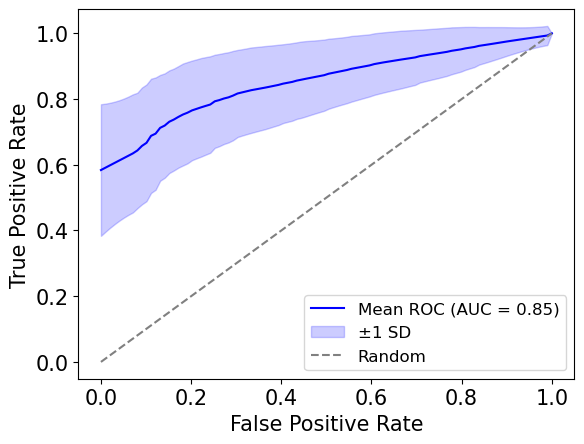

In [8]:
all_fpr = []
all_tpr = []
all_auc = []

all_classification_reports = []
all_predictions = pd.DataFrame(columns=['Fold', 'Actual_Labels', 'Predicted_Labels'])

random_state = 12883823
rkf = RepeatedKFold(n_splits=2, n_repeats=100, random_state=random_state)

for i, (train_index, test_index) in enumerate(rkf.split(X1)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")
    
    X_train, X_test = X1.iloc[train_index], X1.iloc[test_index]
    Y_train, Y_test = Y.iloc[train_index], Y.iloc[test_index]
    
    
    rrt = RandomForestClassifier(n_estimators=10, n_jobs=-1) 
    rrt.fit(X_train, Y_train)
    pred_values = rrt.predict(X_test)
    report = classification_report(Y_test, pred_values, output_dict=True)
    all_classification_reports.append(report)
    
    print(classification_report(Y_test, pred_values, output_dict=True))
    print(Y_test)
    print(pred_values)

    # Get class probabilities for ROC curve
    probas_ = rrt.predict_proba(X_test)
    fpr, tpr, thresholds = roc_curve(Y_test, probas_[:, 1])
    
    acc = accuracy_score(Y_test,pred_values)
    print('Accuracy: {}'.format(acc))
    all_acc.append(acc)
    roc_auc = auc(fpr, tpr)
    print('AUC: {}'.format(roc_auc))
    
    # Store results for later plotting
    all_fpr.append(fpr)
    all_tpr.append(tpr)
    all_auc.append(roc_auc)
 
    
# Calculate mean and standard deviation of fpr and tpr
mean_fpr = np.linspace(0, 1, 100)
mean_tpr = np.mean([interp(mean_fpr, fpr, tpr) for fpr, tpr in zip(all_fpr, all_tpr)], axis=0)
std_tpr = np.std([interp(mean_fpr, fpr, tpr) for fpr, tpr in zip(all_fpr, all_tpr)], axis=0)

# Plot mean ROC curve with standard deviation
plt.figure()
plt.plot(mean_fpr, mean_tpr, color='b', label=f'Mean ROC (AUC = {np.mean(all_auc):.2f})')
plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr, color='blue', alpha=0.2, label='±1 SD')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('False Positive Rate', fontsize=15)
plt.ylabel('True Positive Rate', fontsize=15)
plt.legend(loc='lower right',fontsize=12)
plt.show()

In [3]:
# Assuming you have X1 and Y defined before this point
rkf = RepeatedKFold(n_splits=2, n_repeats=50, random_state=42)  # Adjust the parameters as needed

all_classification_reports = []
all_predictions = pd.DataFrame(columns=['Fold', 'Index', 'Actual_Labels', 'Predicted_Labels'])

for i, (train_index, test_index) in enumerate(rkf.split(X1)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")

    X_train, X_test = X1.iloc[train_index], X1.iloc[test_index]
    Y_train, Y_test = Y.iloc[train_index], Y.iloc[test_index]

    rrt = RandomForestClassifier(n_estimators=100, n_jobs=-1)
    rrt.fit(X_train, Y_train)
    pred_values = rrt.predict(X_test)
    report = classification_report(Y_test, pred_values, output_dict=True)
    all_classification_reports.append(report)

    fold_data = pd.DataFrame({
        'Fold': np.repeat(i, len(Y_test)),
        'Index': Y_test.index,
        'Actual_Labels': Y_test.values.flatten(),
        'Predicted_Labels': pred_values.flatten()
    })
    all_predictions = pd.concat([all_predictions, fold_data], ignore_index=True)

    print(classification_report(Y_test, pred_values, output_dict=True))
    print(Y_test)
    print(pred_values)

all_predictions.to_csv('predictions.csv', index=False)

Fold 0:
  Train: index=[ 1  2  3  6  7 10 14 18 19 20 21 25 26 28 30]
  Test:  index=[ 0  4  5  8  9 11 12 13 15 16 17 22 23 24 27 29]
{'0.0': {'precision': 0.8181818181818182, 'recall': 1.0, 'f1-score': 0.9, 'support': 9}, '1.0': {'precision': 1.0, 'recall': 0.7142857142857143, 'f1-score': 0.8333333333333333, 'support': 7}, 'accuracy': 0.875, 'macro avg': {'precision': 0.9090909090909092, 'recall': 0.8571428571428572, 'f1-score': 0.8666666666666667, 'support': 16}, 'weighted avg': {'precision': 0.8977272727272727, 'recall': 0.875, 'f1-score': 0.8708333333333333, 'support': 16}}
    y_label
0       0.0
4       0.0
5       0.0
8       1.0
9       0.0
11      0.0
12      0.0
13      0.0
15      0.0
16      1.0
17      0.0
22      1.0
23      1.0
24      1.0
27      1.0
29      1.0
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1.]
Fold 1:
  Train: index=[ 0  4  5  8  9 11 12 13 15 16 17 22 23 24 27 29]
  Test:  index=[ 1  2  3  6  7 10 14 18 19 20 21 25 26 28 30]
{'0.0': {'precision': 0.8

{'0.0': {'precision': 0.9, 'recall': 0.9, 'f1-score': 0.9, 'support': 10}, '1.0': {'precision': 0.8333333333333334, 'recall': 0.8333333333333334, 'f1-score': 0.8333333333333334, 'support': 6}, 'accuracy': 0.875, 'macro avg': {'precision': 0.8666666666666667, 'recall': 0.8666666666666667, 'f1-score': 0.8666666666666667, 'support': 16}, 'weighted avg': {'precision': 0.875, 'recall': 0.875, 'f1-score': 0.875, 'support': 16}}
    y_label
0       0.0
1       0.0
2       0.0
5       0.0
7       0.0
8       1.0
11      0.0
13      0.0
15      0.0
17      0.0
21      0.0
22      1.0
24      1.0
25      1.0
29      1.0
30      1.0
[0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 1. 1. 1.]
Fold 11:
  Train: index=[ 0  1  2  5  7  8 11 13 15 17 21 22 24 25 29 30]
  Test:  index=[ 3  4  6  9 10 12 14 16 18 19 20 23 26 27 28]
{'0.0': {'precision': 0.8, 'recall': 1.0, 'f1-score': 0.888888888888889, 'support': 8}, '1.0': {'precision': 1.0, 'recall': 0.7142857142857143, 'f1-score': 0.8333333333333333, 'support

{'0.0': {'precision': 0.8, 'recall': 1.0, 'f1-score': 0.888888888888889, 'support': 8}, '1.0': {'precision': 1.0, 'recall': 0.75, 'f1-score': 0.8571428571428571, 'support': 8}, 'accuracy': 0.875, 'macro avg': {'precision': 0.9, 'recall': 0.875, 'f1-score': 0.873015873015873, 'support': 16}, 'weighted avg': {'precision': 0.9, 'recall': 0.875, 'f1-score': 0.873015873015873, 'support': 16}}
    y_label
2       0.0
3       0.0
4       0.0
6       0.0
8       1.0
9       0.0
10      0.0
14      0.0
17      0.0
19      1.0
23      1.0
25      1.0
27      1.0
28      1.0
29      1.0
30      1.0
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 1. 1. 1.]
Fold 23:
  Train: index=[ 2  3  4  6  8  9 10 14 17 19 23 25 27 28 29 30]
  Test:  index=[ 0  1  5  7 11 12 13 15 16 18 20 21 22 24 26]
{'0.0': {'precision': 0.875, 'recall': 0.7, 'f1-score': 0.7777777777777777, 'support': 10}, '1.0': {'precision': 0.5714285714285714, 'recall': 0.8, 'f1-score': 0.6666666666666666, 'support': 5}, 'accuracy': 0.7333333333

{'0.0': {'precision': 0.9, 'recall': 1.0, 'f1-score': 0.9473684210526316, 'support': 9}, '1.0': {'precision': 1.0, 'recall': 0.8571428571428571, 'f1-score': 0.923076923076923, 'support': 7}, 'accuracy': 0.9375, 'macro avg': {'precision': 0.95, 'recall': 0.9285714285714286, 'f1-score': 0.9352226720647774, 'support': 16}, 'weighted avg': {'precision': 0.94375, 'recall': 0.9375, 'f1-score': 0.936740890688259, 'support': 16}}
    y_label
2       0.0
5       0.0
6       0.0
7       0.0
8       1.0
10      0.0
13      0.0
14      0.0
17      0.0
19      1.0
21      0.0
22      1.0
24      1.0
26      1.0
27      1.0
29      1.0
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1. 1. 1. 1.]
Fold 35:
  Train: index=[ 2  5  6  7  8 10 13 14 17 19 21 22 24 26 27 29]
  Test:  index=[ 0  1  3  4  9 11 12 15 16 18 20 23 25 28 30]
{'0.0': {'precision': 0.8181818181818182, 'recall': 1.0, 'f1-score': 0.9, 'support': 9}, '1.0': {'precision': 1.0, 'recall': 0.6666666666666666, 'f1-score': 0.8, 'support': 6}, 'accura

{'0.0': {'precision': 0.6, 'recall': 0.75, 'f1-score': 0.6666666666666665, 'support': 8}, '1.0': {'precision': 0.6666666666666666, 'recall': 0.5, 'f1-score': 0.5714285714285715, 'support': 8}, 'accuracy': 0.625, 'macro avg': {'precision': 0.6333333333333333, 'recall': 0.625, 'f1-score': 0.6190476190476191, 'support': 16}, 'weighted avg': {'precision': 0.6333333333333333, 'recall': 0.625, 'f1-score': 0.6190476190476191, 'support': 16}}
    y_label
0       0.0
1       0.0
5       0.0
6       0.0
7       0.0
8       1.0
9       0.0
11      0.0
13      0.0
16      1.0
19      1.0
22      1.0
23      1.0
24      1.0
25      1.0
29      1.0
[0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1. 1. 0. 1.]
Fold 47:
  Train: index=[ 0  1  5  6  7  8  9 11 13 16 19 22 23 24 25 29]
  Test:  index=[ 2  3  4 10 12 14 15 17 18 20 21 26 27 28 30]
{'0.0': {'precision': 0.8888888888888888, 'recall': 0.8, 'f1-score': 0.8421052631578948, 'support': 10}, '1.0': {'precision': 0.6666666666666666, 'recall': 0.8, 'f1-score'

{'0.0': {'precision': 0.8181818181818182, 'recall': 0.8181818181818182, 'f1-score': 0.8181818181818182, 'support': 11}, '1.0': {'precision': 0.6, 'recall': 0.6, 'f1-score': 0.6, 'support': 5}, 'accuracy': 0.75, 'macro avg': {'precision': 0.7090909090909091, 'recall': 0.7090909090909091, 'f1-score': 0.7090909090909091, 'support': 16}, 'weighted avg': {'precision': 0.75, 'recall': 0.75, 'f1-score': 0.75, 'support': 16}}
    y_label
1       0.0
3       0.0
6       0.0
7       0.0
10      0.0
11      0.0
12      0.0
13      0.0
14      0.0
15      0.0
16      1.0
19      1.0
21      0.0
23      1.0
24      1.0
30      1.0
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0.]
Fold 59:
  Train: index=[ 1  3  6  7 10 11 12 13 14 15 16 19 21 23 24 30]
  Test:  index=[ 0  2  4  5  8  9 17 18 20 22 25 26 27 28 29]
{'0.0': {'precision': 0.7, 'recall': 1.0, 'f1-score': 0.8235294117647058, 'support': 7}, '1.0': {'precision': 1.0, 'recall': 0.625, 'f1-score': 0.7692307692307693, 'support': 8}, 'accuracy

{'0.0': {'precision': 0.6666666666666666, 'recall': 0.6666666666666666, 'f1-score': 0.6666666666666666, 'support': 9}, '1.0': {'precision': 0.5714285714285714, 'recall': 0.5714285714285714, 'f1-score': 0.5714285714285714, 'support': 7}, 'accuracy': 0.625, 'macro avg': {'precision': 0.6190476190476191, 'recall': 0.6190476190476191, 'f1-score': 0.6190476190476191, 'support': 16}, 'weighted avg': {'precision': 0.625, 'recall': 0.625, 'f1-score': 0.625, 'support': 16}}
    y_label
0       0.0
3       0.0
6       0.0
7       0.0
9       0.0
12      0.0
15      0.0
18      0.0
19      1.0
21      0.0
24      1.0
25      1.0
26      1.0
27      1.0
28      1.0
30      1.0
[0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 1. 0.]
Fold 71:
  Train: index=[ 0  3  6  7  9 12 15 18 19 21 24 25 26 27 28 30]
  Test:  index=[ 1  2  4  5  8 10 11 13 14 16 17 20 22 23 29]
{'0.0': {'precision': 0.75, 'recall': 1.0, 'f1-score': 0.8571428571428571, 'support': 9}, '1.0': {'precision': 1.0, 'recall': 0.5, 'f1-score

{'0.0': {'precision': 1.0, 'recall': 0.5384615384615384, 'f1-score': 0.7000000000000001, 'support': 13}, '1.0': {'precision': 0.3333333333333333, 'recall': 1.0, 'f1-score': 0.5, 'support': 3}, 'accuracy': 0.625, 'macro avg': {'precision': 0.6666666666666666, 'recall': 0.7692307692307692, 'f1-score': 0.6000000000000001, 'support': 16}, 'weighted avg': {'precision': 0.875, 'recall': 0.625, 'f1-score': 0.6625000000000001, 'support': 16}}
    y_label
0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
5       0.0
9       0.0
11      0.0
12      0.0
13      0.0
14      0.0
15      0.0
18      0.0
26      1.0
27      1.0
29      1.0
[1. 1. 0. 0. 0. 0. 0. 1. 1. 0. 0. 1. 1. 1. 1. 1.]
Fold 83:
  Train: index=[ 0  1  2  3  4  5  9 11 12 13 14 15 18 26 27 29]
  Test:  index=[ 6  7  8 10 16 17 19 20 21 22 23 24 25 28 30]
{'0.0': {'precision': 0.38461538461538464, 'recall': 1.0, 'f1-score': 0.5555555555555556, 'support': 5}, '1.0': {'precision': 1.0, 'recall': 0.2, 'f1-score': 0.33333333333

{'0.0': {'precision': 0.8, 'recall': 1.0, 'f1-score': 0.888888888888889, 'support': 8}, '1.0': {'precision': 1.0, 'recall': 0.75, 'f1-score': 0.8571428571428571, 'support': 8}, 'accuracy': 0.875, 'macro avg': {'precision': 0.9, 'recall': 0.875, 'f1-score': 0.873015873015873, 'support': 16}, 'weighted avg': {'precision': 0.9, 'recall': 0.875, 'f1-score': 0.873015873015873, 'support': 16}}
    y_label
2       0.0
4       0.0
5       0.0
7       0.0
8       1.0
11      0.0
14      0.0
15      0.0
17      0.0
19      1.0
22      1.0
23      1.0
26      1.0
27      1.0
28      1.0
29      1.0
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1.]
Fold 95:
  Train: index=[ 2  4  5  7  8 11 14 15 17 19 22 23 26 27 28 29]
  Test:  index=[ 0  1  3  6  9 10 12 13 16 18 20 21 24 25 30]
{'0.0': {'precision': 0.8333333333333334, 'recall': 1.0, 'f1-score': 0.9090909090909091, 'support': 10}, '1.0': {'precision': 1.0, 'recall': 0.6, 'f1-score': 0.7499999999999999, 'support': 5}, 'accuracy': 0.866666666666

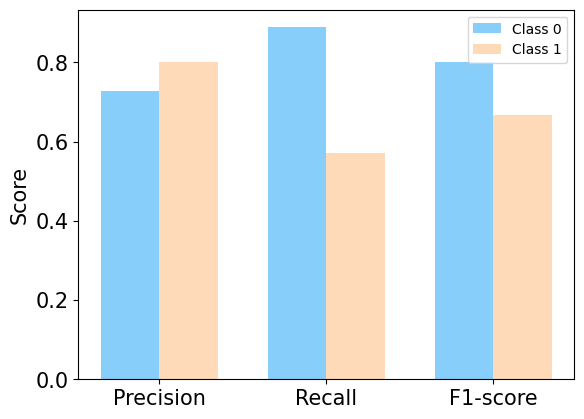

In [11]:
# This code performs a breakdown of the results
precision_class_0 = []
recall_class_0 = []
f1_class_0 = []

precision_class_1 = []
recall_class_1 = []
f1_class_1 = []

for report in all_classification_reports1:
    precision_class_0.append(report['0.0']['precision'])
    recall_class_0.append(report['0.0']['recall'])
    f1_class_0.append(report['0.0']['f1-score'])

    precision_class_1.append(report['1.0']['precision'])
    recall_class_1.append(report['1.0']['recall'])
    f1_class_1.append(report['1.0']['f1-score'])

# Calculate average precision, recall, and f1-score for each class
avg_precision_class_0 = np.mean(precision_class_0)
avg_recall_class_0 = np.mean(recall_class_0)
avg_f1_class_0 = np.mean(f1_class_0)

avg_precision_class_1 = np.mean(precision_class_1)
avg_recall_class_1 = np.mean(recall_class_1)
avg_f1_class_1 = np.mean(f1_class_1)

# Plot bar plot for average precision, recall, and f1-score for each class
labels = ['Precision', 'Recall', 'F1-score']
class_0_values = [avg_precision_class_0, avg_recall_class_0, avg_f1_class_0]
class_1_values = [avg_precision_class_1, avg_recall_class_1, avg_f1_class_1]

bar_width = 0.35
index = np.arange(len(labels))

plt.bar(index, class_0_values, bar_width, color='lightskyblue', label='Class 0')
plt.bar(index + bar_width, class_1_values, bar_width, color='peachpuff',label='Class 1')

#plt.xlabel('Metric')
plt.ylabel('Score',fontsize=15)
#plt.title('Average Precision, Recall, and F1-score for Each Class')
plt.xticks(index + bar_width / 2, labels)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend()
plt.show()

In [131]:
pca = PCA(n_components=2)
distance_pca1 = pca.fit_transform(X)

km = KMeans(n_clusters=2)
km


y_predicted1 = km.fit_predict(distance_pca1)
print(y_predicted1)



y_predicted2 = km.fit_predict(X1)
print(y_predicted2)
df1['cluster']= y_predicted2

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 1 1 1 0 1]


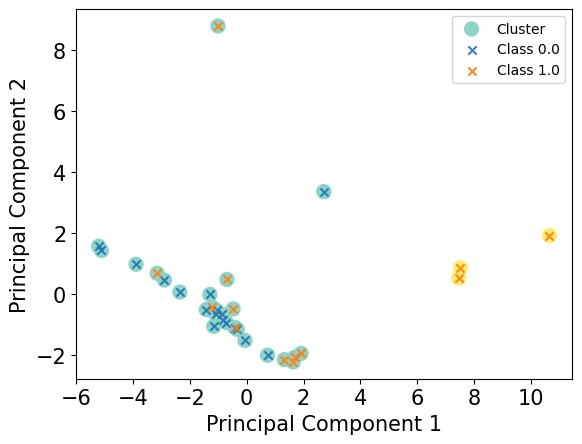

In [148]:
# Plotting the two clusters based on PCA
plt.scatter(distance_pca1[:, 0], distance_pca1[:, 1], c=y_predicted1, cmap='Set3', marker='o', s=100, alpha=1.0, label='Cluster')

# Mark the original y values with a different marker or color
unique_labels = df1['y_label'].unique()
for label in unique_labels:
    cluster_points = distance_pca1[df1['y_label'] == label]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], marker='x',alpha=0.9, label=f'Class {label}')

plt.xlabel('Principal Component 1',fontsize=15)
plt.ylabel('Principal Component 2',fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend()
plt.show()

In [101]:
df_pred = pd.read_csv('predictions.csv') 

X_pred = df_pred.iloc[0:31,[5]]
Y_pred = df_pred.iloc[0:31,[8]]

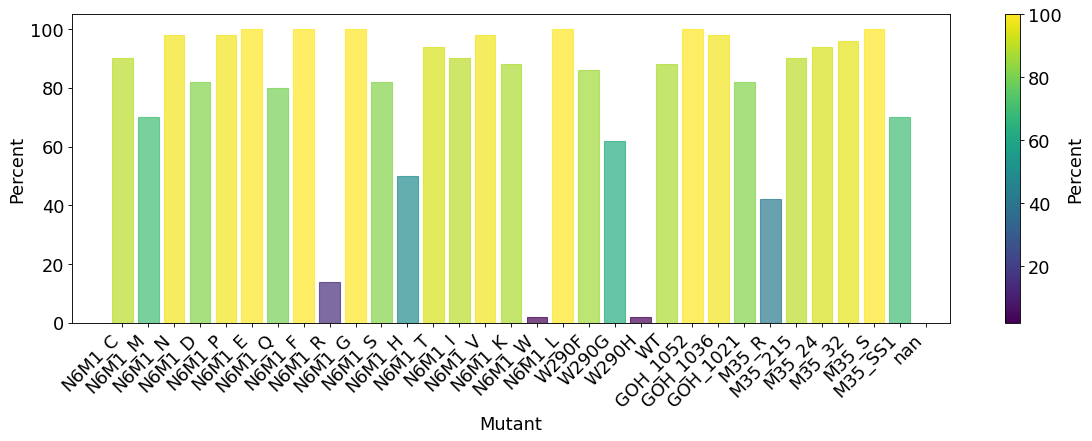

In [108]:
# Analyze the individual effect of mutants

figure(figsize=(15, 5.8), dpi=80)
plt.rcParams['font.size'] = 16

df_pred = df_pred.dropna(subset=['Mutant'])
df_pred['Mutant'] = df_pred['Mutant'].astype(str)

# Define a colormap
cmap = plt.cm.get_cmap('viridis')
norm = Normalize(vmin=df_pred['Percent_actual'].min(), vmax=df_pred['Percent_actual'].max())
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Empty array for the data range
bars = plt.bar(df_pred['Mutant'], df_pred['Percent_actual'], color=cmap(norm(df_pred['Percent_actual'])), alpha=0.7)
cbar = plt.colorbar(sm)
cbar.set_label('Percent')

plt.xlabel('Mutant')
plt.ylabel('Percent')
plt.xticks(rotation=45, ha='right')  # Rotate X-axis labels for better visibility


for bar, color in zip(bars, cmap(norm(df_pred['Percent_actual']))):
    bar.set_color(color)

plt.tight_layout()
plt.show()